In [19]:
import pandas as pd 
from google import genai
import pandas as pd
import random
import re
import time
import numpy as np
import os

os.chdir('/Users/philipp/desktop/ML_in_Applied_Settings')
# print current directory
print(os.getcwd())

# optimize printed dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

/Users/philipp/Desktop/ML_in_Applied_Settings


In [20]:
#%pip uninstall google-generativeai google-genai -y
#%pip install -U google-genai


In [ ]:
client = genai.Client(api_key="")

# Listet alle verfügbaren Modelle auf
for model in client.models.list():
    print(f"Name: {model.name} | Version: {model.version}")

Name: models/gemini-2.5-flash | Version: 001
Name: models/gemini-2.5-pro | Version: 2.5
Name: models/gemini-2.0-flash | Version: 2.0
Name: models/gemini-2.0-flash-001 | Version: 2.0
Name: models/gemini-2.0-flash-lite-001 | Version: 2.0
Name: models/gemini-2.0-flash-lite | Version: 2.0
Name: models/gemini-2.5-flash-preview-tts | Version: gemini-2.5-flash-exp-tts-2025-05-19
Name: models/gemini-2.5-pro-preview-tts | Version: gemini-2.5-pro-preview-tts-2025-05-19
Name: models/gemma-4-26b-a4b-it | Version: 001
Name: models/gemma-4-31b-it | Version: 001
Name: models/gemini-flash-latest | Version: Gemini Flash Latest
Name: models/gemini-flash-lite-latest | Version: Gemini Flash-Lite Latest
Name: models/gemini-pro-latest | Version: Gemini Pro Latest
Name: models/gemini-2.5-flash-lite | Version: 001
Name: models/gemini-2.5-flash-image | Version: 2.0
Name: models/gemini-3-pro-preview | Version: 3-pro-preview-11-2025
Name: models/gemini-3-flash-preview | Version: 3-flash-preview-12-2025
Name: mod

In [ ]:
# The client gets the API key from the environment variable `GEMINI_API_KEY`.
GEMINI_API_KEY = ''

client = genai.Client(api_key=GEMINI_API_KEY)

# Test model respone

response = client.models.generate_content(model="gemma-4-31b-it", contents="Explain how AI works in a few words")

print(response.text)

Finding patterns in data to make predictions.


In [24]:
human_df = pd.read_csv("human_reviews_labeled.csv", sep="\t")
human_df = human_df[['rating', 'title', 'text', "category"]]

In [ ]:
GEMINI_API_KEY = ''
GLOBAL_SEED = 42

# 1. API Konfiguration
# Ersetze 'DEIN_API_KEY' durch deinen echten Key von https://aistudio.google.com/
client = genai.Client(api_key=GEMINI_API_KEY)

raw_sizes = {
    "Home_and_Kitchen": 67_400_000,
    "Clothing_Shoes_and_Jewelry": 66_000_000,
    "Electronics": 43_900_000,
    "Books": 29_500_000,
    "Tools_and_Home_Improvement": 27_000_000,
    "Health_and_Household": 25_600_000,
    "Kindle_Store": 25_600_000,
    "Beauty_and_Personal_Care": 23_900_000,
    "Cell_Phones_and_Accessories": 20_800_000,
    "Automotive": 20_000_000
}

# Ensure the order matches your 'categories' list exactly
categories = list(raw_sizes.keys())
sizes_vector = np.array(list(raw_sizes.values()))

# Calculate probabilities (must sum to 1.0)
category_probabilities = sizes_vector / sizes_vector.sum()

# Falls du eine bestimmte Verteilung möchtest:
# 1. Definition der Verteilung (Sauber sortiert von 1 bis 5)
# Die Wahrscheinlichkeiten müssen exakt an derselben Index-Position stehen wie die Sterne
star_pool = [1, 2, 3, 4, 5]

star_probabilities = [
    0.0822,  # Wahrscheinlichkeit für 1 Stern
    0.0488,  # Wahrscheinlichkeit für 2 Sterne
    0.0738,  # Wahrscheinlichkeit for 3 Sterne
    0.1160,  # Wahrscheinlichkeit für 4 Sterne
    0.6792   # Wahrscheinlichkeit für 5 Sterne
]

def generate_batch(n=10, batch_index=0):
    reviews = []
    # Ensure reproducibility
    random.seed(GLOBAL_SEED + batch_index)
    np.random.seed(GLOBAL_SEED + batch_index)

    selected_category = np.random.choice(
        categories, 
        p=category_probabilities
    )
    
    # Generate weighted star ratings
    target_stars = np.random.choice(
        star_pool, 
        size=n, 
        p=star_probabilities
    )
    stars_instruction = ", ".join(map(str, target_stars))

    # sample reviews 
    sampled_rev = human_df[human_df["category"] == selected_category].sample(n=5)

    prompt = f"""Generate exactly {n} Amazon product reviews in English within this category: {selected_category}. 
    Vary the reviews in length, so they are more human like.
Star ratings (please adhere strictly): {stars_instruction}

STRICTLY adhere to this format:

###REVIEW###
PRODUCT: [Name]
STARS: [Number]
TITLE: [Title]
TEXT: [Review]
###END###

Use these reviews as an example: {sampled_rev}

Now generate {n} new reviews:"""


    try:
        # API Aufruf mit dem neuen Client
        response = client.models.generate_content(
            model="gemma-4-31b-it",
            contents=prompt
        )
        
        response_text = response.text

        # Regex zum Extrahieren der Daten
        pattern = re.compile(
            r'###REVIEW###.*?PRODUCT:\s*(.*?)\n.*?STARS:\s*(\d).*?TITLE:\s*(.*?)\n.*?TEXT:\s*(.*?)\s*###END###',
            re.DOTALL | re.IGNORECASE
        )

        blocks = pattern.findall(response_text)

        for produkt, sterne, titel, text in blocks:
            reviews.append({
                "category": selected_category,
                "product": produkt.strip(),
                "rating":  int(sterne.strip()),
                "title":   titel.strip(),
                "text":    text.strip().replace("\n", " ")
            })

    except Exception as e:
        print(f"⚠️ Error in API-Call: {e}")
        return []

    return reviews

def generate_all(total_n=1000, chunk_size=10):
    all_reviews = []
    batch_counter = 0

    while len(all_reviews) < total_n:
        print(f"Progress: {len(all_reviews)}/{total_n}...")

        try:
            new_batch = generate_batch(n=chunk_size, batch_index=batch_counter)

            if not new_batch:
                print("⚠️ Parsing failed or empty batch.. Wait and try again...")
                time.sleep(2)
                continue
            batch_counter += 1

            all_reviews.extend(new_batch)
            
            # Speichern als Checkpoint
            df = pd.DataFrame(all_reviews)
            df.to_csv("checkpoint.csv", index=False)
            
            # Kurze Pause für das Rate-Limit (Free Tier: 15 RPM)
            time.sleep(4)

        except Exception as e:
            print(f"❌ Critical error in Loop: {e}")
            time.sleep(5)

    return all_reviews[:total_n]

# Start der Generierung
all_reviews = generate_all(total_n=5000, chunk_size=10)
print("✅ Generation completed!")


Progress: 0/5000...
⚠️ Error in API-Call: 500 INTERNAL. {'error': {'code': 500, 'message': 'Internal error encountered.', 'status': 'INTERNAL'}}
⚠️ Parsing failed or empty batch.. Wait and try again...
Progress: 0/5000...
⚠️ Error in API-Call: 500 INTERNAL. {'error': {'code': 500, 'message': 'Internal error encountered.', 'status': 'INTERNAL'}}
⚠️ Parsing failed or empty batch.. Wait and try again...
Progress: 0/5000...
⚠️ Error in API-Call: 500 INTERNAL. {'error': {'code': 500, 'message': 'Internal error encountered.', 'status': 'INTERNAL'}}
⚠️ Parsing failed or empty batch.. Wait and try again...
Progress: 0/5000...
⚠️ Error in API-Call: 500 INTERNAL. {'error': {'code': 500, 'message': 'Internal error encountered.', 'status': 'INTERNAL'}}
⚠️ Parsing failed or empty batch.. Wait and try again...
Progress: 0/5000...
Progress: 10/5000...
⚠️ Error in API-Call: 500 INTERNAL. {'error': {'code': 500, 'message': 'Internal error encountered.', 'status': 'INTERNAL'}}
⚠️ Parsing failed or empty

In [ ]:
# Die magische Zeile
df = pd.DataFrame(all_reviews)

# Jetzt kannst du damit arbeiten
print(df
)

                        category                 product  rating                       title                                               text
0     Clothing_Shoes_and_Jewelry       Cotton V-Neck Tee       5                   Great fit             Fits perfectly and the fabric is soft.
1     Clothing_Shoes_and_Jewelry    Gold Plated Earrings       5                   Stunning!  I wore these to a wedding and got so many comp...
2     Clothing_Shoes_and_Jewelry     Trail Running Shoes       5                Game changer  Finally found a pair that doesn't give me blis...
3     Clothing_Shoes_and_Jewelry  Oversized Denim Jacket       3     Okay, but sizing is off  The quality of the denim is good, but it's way...
4     Clothing_Shoes_and_Jewelry     High-Waist Leggings       3                     Average  They are fine for the price, but they start to...
...                          ...                     ...     ...                         ...                                            

In [ ]:
df

,category,product,rating,title,text
0,Clothing_Shoes_and_Jewelry,Cotton V-Neck Tee,5,Great fit,Fits perfectly and the fabric is soft.
1,Clothing_Shoes_and_Jewelry,Gold Plated Earrings,5,Stunning!,I wore these to a wedding and got so many comp...
2,Clothing_Shoes_and_Jewelry,Trail Running Shoes,5,Game changer,Finally found a pair that doesn't give me blis...
3,Clothing_Shoes_and_Jewelry,Oversized Denim Jacket,3,"Okay, but sizing is off","The quality of the denim is good, but it's way..."
4,Clothing_Shoes_and_Jewelry,High-Waist Leggings,3,Average,"They are fine for the price, but they start to..."
...,...,...,...,...,...
4995,Books,Gardening 101,5,Great for beginners,Helped me start my first vegetable garden!
4996,Books,Mystery at the Manor,5,Couldn't put it down,A gripping page-turner with a twist I never sa...
4997,Books,History of the World,5,Educational,Very thorough and well-researched. A great add...
4998,Books,Quick Math Tricks,1,Waste of money,The explanations are confusing and several pag...


In [ ]:
df.to_csv("/Users/philipp/desktop/df_API_test_2.csv", index=False, encoding="utf-8", sep="\t")



NameError: name 'plt' is not defined

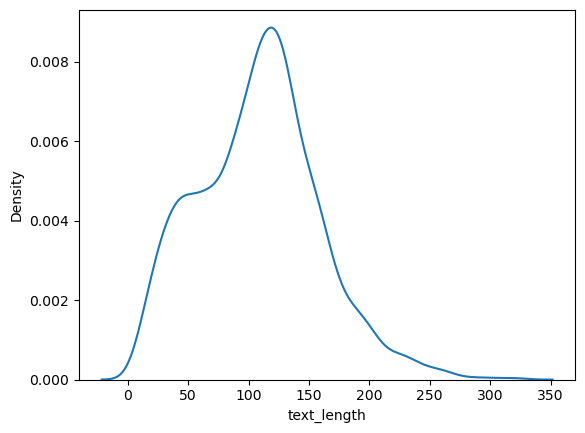

In [ ]:
import seaborn as sns
df["text_length"] = df["text"].apply(lambda x: len(x))
sns.kdeplot(df, x="text_length")
plt.show()